In [1]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


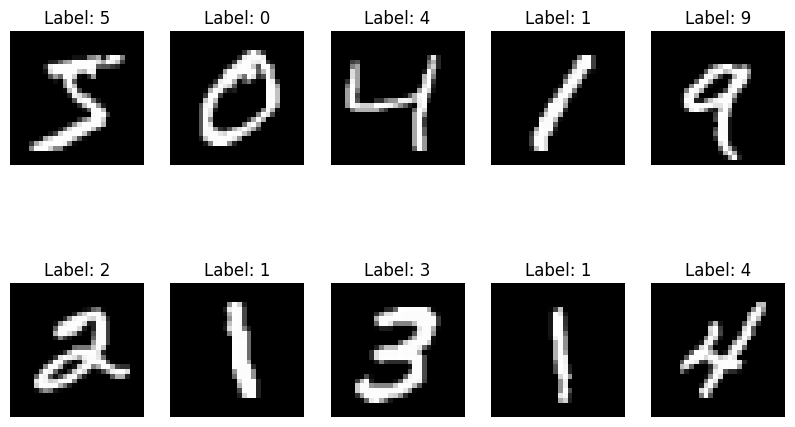

In [5]:
plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title("Label: {}".format(y_train[i]))

    plt.axis('off')

plt.show()

In [6]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [7]:
X_train = X_train.reshape(60000,28,28,1)

X_test = X_test.reshape(10000,28,28,1)

In [8]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.9398 - loss: 0.1929 - val_accuracy: 0.9836 - val_loss: 0.0538
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9805 - loss: 0.0655 - val_accuracy: 0.9871 - val_loss: 0.0435
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 35ms/step - accuracy: 0.9858 - loss: 0.0458 - val_accuracy: 0.9898 - val_loss: 0.0365
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.9887 - loss: 0.0352 - val_accuracy: 0.9910 - val_loss: 0.0312
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9907 - loss: 0.0290 - val_accuracy: 0.9908 - val_loss: 0.0346
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9923 - loss: 0.0235 - val_accuracy: 0.9908 - val_loss: 0.0352
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.9935 - loss: 0.0204 - val_accuracy: 0.9906 - val_loss: 0.0370
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9943 -

In [14]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

print("Test Loss:",loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9933 - loss: 0.0244
Test Accuracy: 0.9933000206947327
Test Loss: 0.02435111626982689


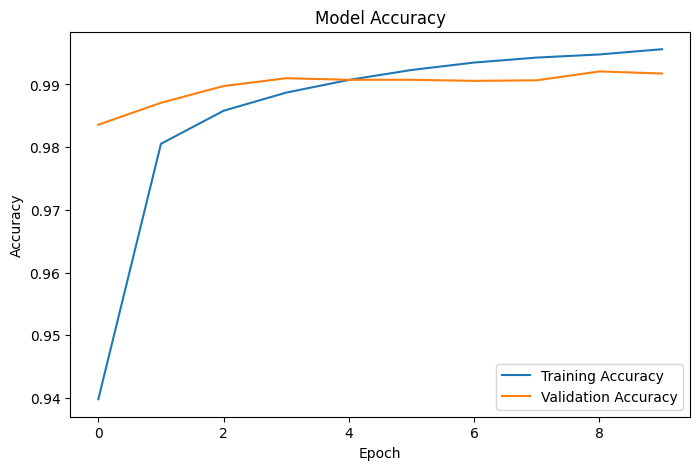

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')

plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

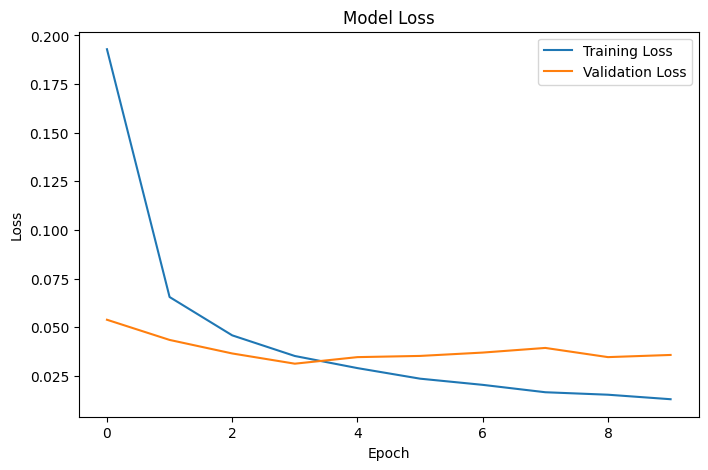

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [17]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions,axis=1)

true_classes = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


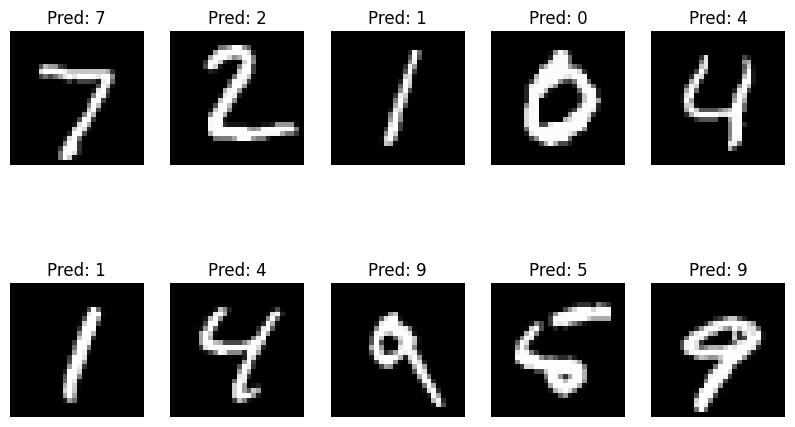

In [18]:
plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(28,28),cmap='gray')

    plt.title("Pred: {}".format(predicted_classes[i]))

    plt.axis('off')

plt.show()

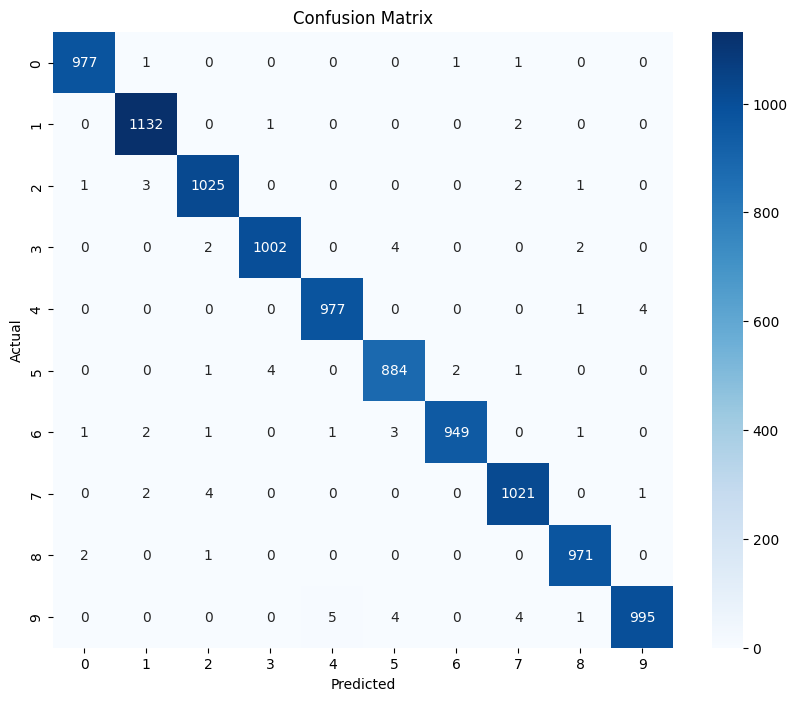

In [19]:
cm = confusion_matrix(true_classes,predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [20]:
print(classification_report(true_classes,predicted_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



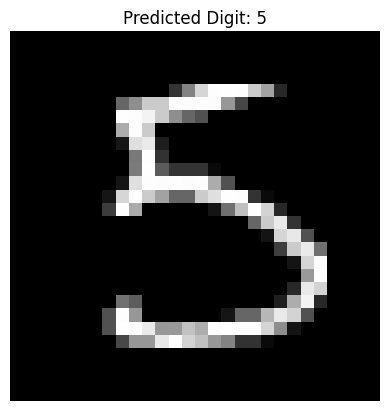

Actual Digit: 5


In [21]:
index = 15

plt.imshow(X_test[index].reshape(28,28),cmap='gray')

plt.title("Predicted Digit: {}".format(predicted_classes[index]))

plt.axis('off')

plt.show()

print("Actual Digit:",true_classes[index])

In [22]:
model.save("handwritten_digit_cnn.keras")

In [24]:
print("Conclusion")
print()
print("A Convolutional Neural Network (CNN) was successfully trained on the MNIST dataset to recognize handwritten digits.")
print("The model achieved high accuracy on the test dataset and can correctly classify handwritten digits from 0 to 9.")
print("This project demonstrates the effectiveness of CNNs in image classification tasks and can be extended to recognize handwritten alphabets or complete words using more advanced sequence models.")

Conclusion

A Convolutional Neural Network (CNN) was successfully trained on the MNIST dataset to recognize handwritten digits.
The model achieved high accuracy on the test dataset and can correctly classify handwritten digits from 0 to 9.
This project demonstrates the effectiveness of CNNs in image classification tasks and can be extended to recognize handwritten alphabets or complete words using more advanced sequence models.
